In [2]:
from numba import njit # DO NOT REMOVE
from functools import partial

from astropy.coordinates import cartesian_to_spherical
from matplotlib import ticker

from pylupnt.crater_detection.common.conics import (
    plot_conics,
    ConicProjector,
    ellipse_axes,
    scale_det,
    conic_center,
    ellipse_angle,
    conic_matrix,
    MaskGenerator,
)
from pylupnt.crater_detection.common.coordinates import ENU_system
from pylupnt.crater_detection import CraterDetector
from pylupnt.crater_detection.matching import CraterDatabase, CoplanarInvariants
from pylupnt.crater_detection.common.data import DataGenerator
from pylupnt.crater_detection.detection.metrics import gaussian_angle_distance
import pylupnt.crater_detection.common.constants as const
import numpy as np
import numpy.linalg as LA
from sklearn.linear_model import RANSACRegressor, TheilSenRegressor
from scipy.optimize import least_squares, minimize
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
import pylupnt as pnt
import torch
import matplotlib.pyplot as plt

In [3]:
db = CraterDatabase.from_file(
    pnt.utils.find_file("lunar_crater_database_robbins_2018.csv"),
    latlims=(0, 30),
    longlims=(0, 30),
    diamlims=(4, 40),
)

In [4]:
gen = MaskGenerator.from_robbins_dataset(
    file_path=pnt.utils.find_file("lunar_crater_database_robbins_2018.csv"),
    diamlims=(4, 40),
    axis_threshold=(1, 250),
)
gen.set_coordinates(10, 10, 250, convert_to_radians=True)

In [18]:
sigma_pix = 2
A_craters = gen.craters_in_image()

n_det = len(A_craters)
# Add noise
major_det, minor_det = ellipse_axes(A_craters)
psi_det = ellipse_angle(A_craters)
r_craters_det = conic_center(A_craters)

major_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
minor_det += np.random.uniform(-sigma_pix, sigma_pix, size=n_det)
psi_det += np.random.normal(scale=(20 / 180) * np.pi, size=n_det)
r_craters_det += np.random.normal(-sigma_pix, sigma_pix, size=r_craters_det.shape)

A_detections = conic_matrix(major_det, minor_det, psi_det, *r_craters_det.T)

In [19]:
C_cat, r_cat = gen.visible_catalogue_craters()

A_query, r_query, C_query = db.query(
    A_detections, k=10, max_distance=0.05, batch_size=1000
)
A_query.shape, r_query.shape, C_query.shape

((84, 3, 3), (84, 3, 1), (84, 3, 3))

In [20]:
k = np.array([0.0, 0.0, 1.0])[:, None]
S = np.concatenate((np.identity(2), np.zeros((1, 2))), axis=0)

T = gen.T
K = gen.K

B_craters = T @ K.T @ A_query @ K @ LA.inv(T)
T_EM = np.concatenate(ENU_system(r_query), axis=-1)
T_ME = LA.inv(T_EM)

A_ = S.T @ T_ME @ B_craters
A = A_.reshape(-1, 3)
b_ = S.T @ T_ME @ B_craters @ r_query
b = b_.reshape(-1, 1)

In [32]:
A_.shape

(84, 2, 3)

In [21]:
def _model_validator(min_alt=10, max_alt=1000, primary_body_radius=const.RMOON):
    return (
        lambda model, *args: (primary_body_radius + min_alt)
        < LA.norm(model.coef_)
        < (primary_body_radius + max_alt)
    )


degraded_position = gen.position + np.random.randn(3, 1) * 100

ransac = RANSACRegressor(
    residual_threshold=0.05, max_trials=10000, is_model_valid=_model_validator()
)
ransac.fit(A / np.mean(b), b / np.mean(b))
inlier_mask = np.logical_and.reduce(
    ransac.inlier_mask_.reshape(b_.shape), axis=(-1, -2)
)
num_inliers = inlier_mask.sum()

est_pos_lsq, _, _, _ = LA.lstsq(A / 1e6, b / 1e6, rcond=None)

est_pos_ransac = ransac.estimator_.coef_.T
print(f"Least squares:\tPosition error: {LA.norm(est_pos_lsq - gen.position):.2f} km")
print(
    f"RANSAC:\t\tPosition error: {LA.norm(est_pos_ransac - gen.position):.2f} km | Inliers: {num_inliers}"
)

Least squares:	Position error: 401.00 km
RANSAC:		Position error: 183.07 km | Inliers: 22


In [31]:
est_pos_lsq

array([[1559.02507114],
       [ 352.24123607],
       [ 186.60583835]])

In [27]:
est_pos_verified = least_squares(
    lambda x: (b - A @ x[:, None]).squeeze(), x0=ransac.estimator_.coef_.squeeze()
)
print(est_pos_verified.x)

[1559.02507091  352.24123591  186.6058384 ]


In [30]:
# Least squares analytical solution
LA.inv(A.T @ A) @ A.T @ b


array([[1559.02507114],
       [ 352.24123607],
       [ 186.60583835]])

In [9]:
C_inlier, r_inlier = (
    C_query.reshape(-1, 3, 3)[inlier_mask],
    r_query.reshape(-1, 3, 1)[inlier_mask],
)

projector = ConicProjector(position=est_pos_ransac, attitude=gen.T)

A_projected = projector.project_crater_conics(C_inlier, r_inlier)
A_matched = A_query[inlier_mask]

In [10]:
sigma_pix = 5

divergence = gaussian_angle_distance(A_projected, A_matched)

a_i, b_i = ellipse_axes(A_projected)

sigma = (0.85 / np.sqrt(a_i * b_i)) * sigma_pix

reprojection_mask = ((divergence / sigma) ** 2) <= 13.276
A_verified = A_matched[reprojection_mask]
r_verified = r_query[inlier_mask][reprojection_mask]

/Users/guillemcv/Development/NavLab/LuPNT/python/pylupnt/crater_detection/detection/metrics.py:278: RuntimeWarning: invalid value encountered in sqrt
  frac_term = 4 * np.sqrt(LA.det(cov1) * LA.det(cov2)) / (LA.det(cov1 + cov2))
/Users/guillemcv/Development/NavLab/LuPNT/python/pylupnt/crater_detection/detection/metrics.py:279: RuntimeWarning: overflow encountered in exp
  exp_term = np.exp(
/Users/guillemcv/Development/NavLab/LuPNT/python/pylupnt/crater_detection/common/conics.py:145: RuntimeWarning: invalid value encountered in sqrt
  axes = np.sqrt(1 / lambdas)


In [11]:
B_verified = T @ K.T @ A_verified @ K @ LA.inv(T)
T_EM = np.concatenate(ENU_system(r_verified), axis=-1)
T_ME = LA.inv(T_EM)

A_ = S.T @ T_ME @ B_verified
A = A_.reshape(-1, 3)
b_ = S.T @ T_ME @ B_verified @ r_verified
b = b_.reshape(-1, 1)

In [16]:
from scipy.optimize import curve_fit

est_pos_verified = least_squares(
    lambda x: (b - A @ x[:, None]).squeeze(), x0=ransac.estimator_.coef_.squeeze()
)
print(est_pos_verified.x)

LA.norm(est_pos_verified.x[:, None] - gen.position)

[1679.13271971  495.92479691  112.64290711]


374.0518366818186

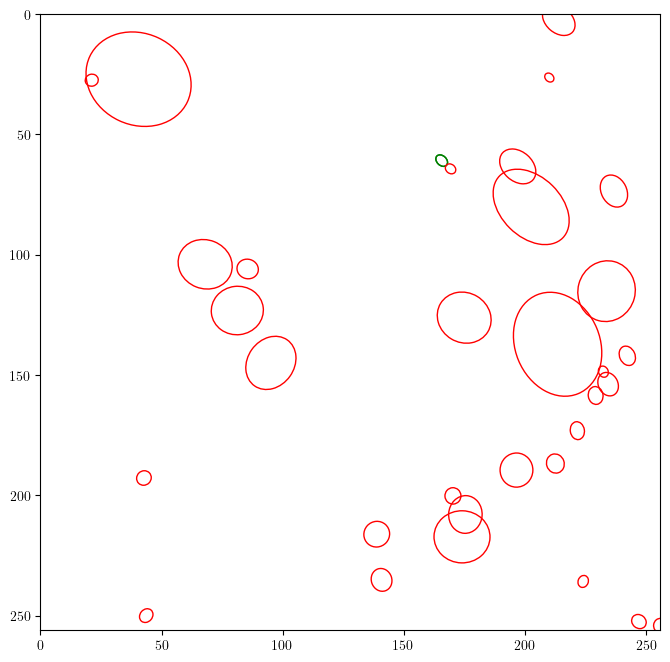

In [34]:
fig, axes = plt.subplots(figsize=(8, 8))
plot_conics(A_verified, ax=axes, rim_color="green")
plot_conics(A_craters, ax=axes)
# plot_conics(A_craters, ax=axes, rim_color='cyan')
# plot_conics(A_projected, ax=axes, rim_color='purple')

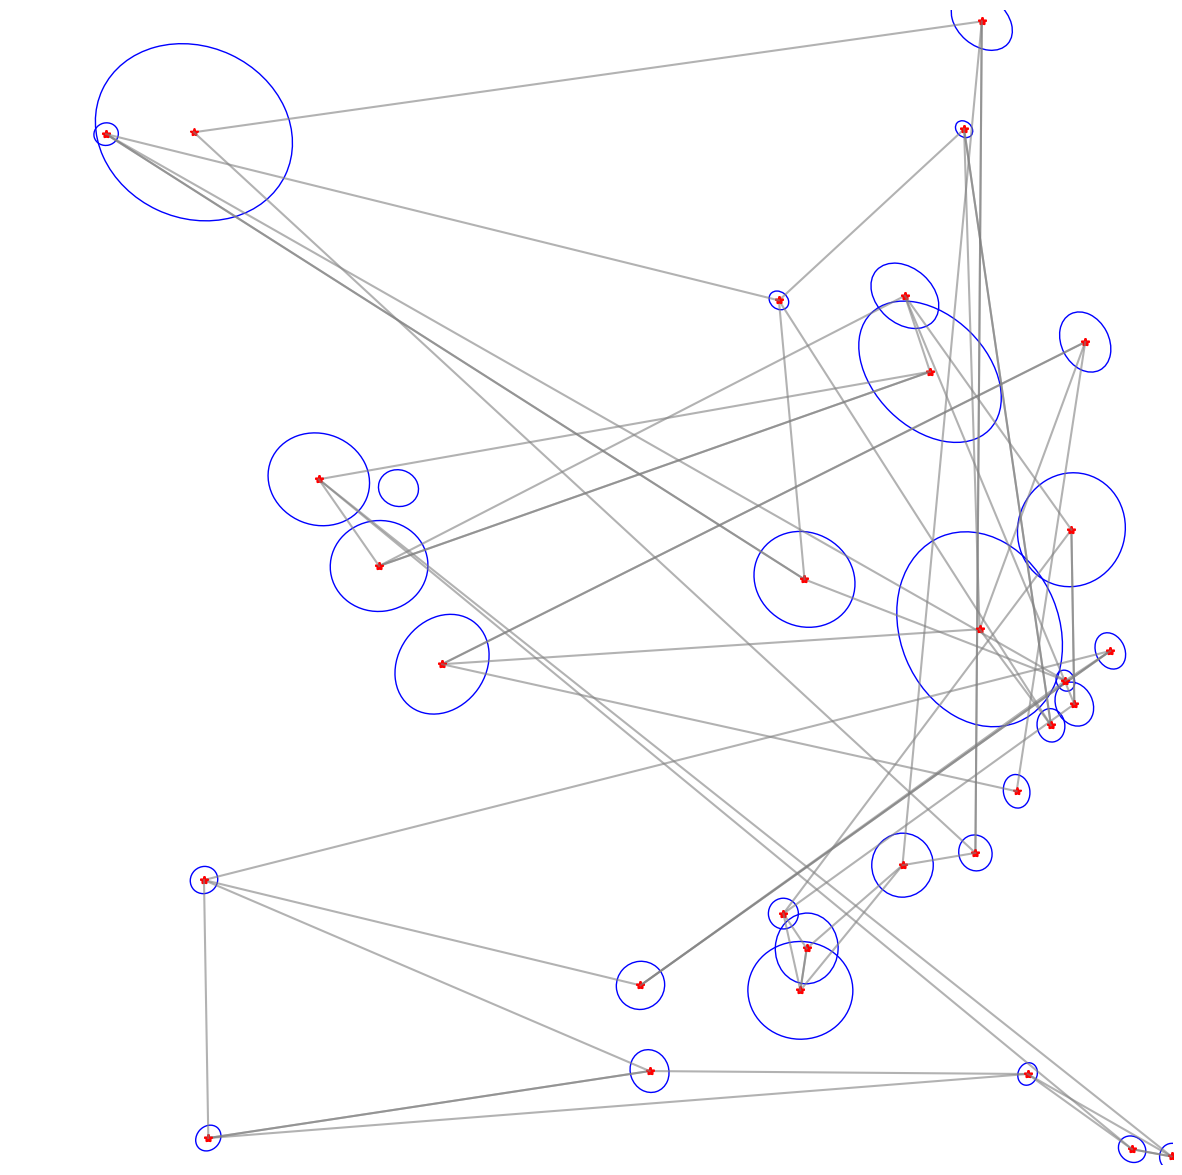

In [35]:
from pylupnt.crater_detection.matching.utils import eps_array
from itertools import combinations

fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, cmap="Greys_r")
ax.axis('off')
plot_conics(A_craters, ax=ax, rim_color='blue')
crater_triads = eps_array(len(A_craters), batch_size=20)
crater_centers = conic_center(A_craters)

for ct in crater_triads:
    for i, j in combinations(ct, 2):
        ci, cj = crater_centers[i], crater_centers[j]
        ax.plot(ci[0], ci[1], 'r*')
        ax.plot(cj[0], cj[1], 'r*')
        ax.plot((ci[0], cj[0]), (ci[1], cj[1]), 'gray', alpha=0.6)


In [36]:
from pylupnt.crater_detection.matching.position_estimation import PositionRegressor

position_regressor = PositionRegressor(residual_threshold=0.1)

In [38]:
np.seterr("ignore")
test_size = 100

attitude_test = np.empty((test_size, 3, 3), np.float64)
true_position_test = np.full((test_size, 3, 1), np.nan, np.float64)
pred_ransac_test = np.full((test_size, 3, 1), np.nan, np.float64)
pred_reprojection_test = np.full((test_size, 3, 1), np.nan, np.float64)
n_detections_test = np.zeros((test_size))
n_inliners_test = np.zeros((test_size))
n_verified_test = np.zeros((test_size))

sigma_pix = 2

matches = 0
errors = 0
for i in range(test_size):
    n_det = 0
    while n_det < 6:
        gen.set_coordinates(np.random.uniform(5, 25), np.random.uniform(5, 25))
        gen.height = np.random.uniform(50, 200)
        gen.point_nadir()
        gen.rotate("roll", np.random.uniform(0, 360))
        gen.rotate("pitch", np.random.uniform(-10, 10))
        gen.rotate("yaw", np.random.uniform(-10, 10))
        A_craters = gen.craters_in_image()
        n_det = len(A_craters)

    attitude_test[i] = gen.attitude
    true_position_test[i] = gen.position

    n_detections_test[i] = n_det
    # Add noise
    major_det, minor_det = ellipse_axes(A_craters)
    psi_det = ellipse_angle(A_craters)
    r_craters_det = conic_center(A_craters)

    major_det += np.random.normal(0, sigma_pix, size=n_det)
    minor_det += np.random.normal(0, sigma_pix, size=n_det)
    psi_det += np.random.normal(scale=(20 / 180) * np.pi, size=n_det)
    r_craters_det += np.random.normal(0, sigma_pix, size=r_craters_det.shape)

    A_detections = conic_matrix(major_det, minor_det, psi_det, *r_craters_det.T)
    try:
        position_regressor = db.query_position(
            A_detections,
            T=gen.T,
            K=gen.K,
            sigma_pix=4,
            k=30,
            max_distance=0.05,
            batch_size=1000,
            residual_threshold=0.05,
            max_trials=2000,
        )
        if position_regressor.ransac_match():
            pred_ransac_test[i] = position_regressor.est_pos_ransac
            n_inliners_test[i] = position_regressor.num_inliers
            print(
                f"[{i:05}]\tRANSAC position error: {LA.norm(position_regressor.est_pos_ransac - gen.position):9.2f} km\t"
                f"| Inliers: {position_regressor.num_inliers}",
                end="\t",
            )

            if position_regressor.reprojection_match():
                pred_reprojection_test[i] = position_regressor.est_pos_verified
                n_verified_test[i] = position_regressor.num_verified
                print(
                    f"Verified position error:  {LA.norm(position_regressor.est_pos_verified - gen.position):9.2f} km",
                    end="",
                )

            print()
            matches += 1
    except ValueError:
        pass

matches

[00000]	RANSAC position error:    581.04 km	| Inliers: 3	
[00002]	RANSAC position error:     84.54 km	| Inliers: 4	
[00005]	RANSAC position error:    244.23 km	| Inliers: 6	
[00010]	RANSAC position error:    305.50 km	| Inliers: 4	
[00011]	RANSAC position error:    218.21 km	| Inliers: 15	Verified position error:     277.55 km
[00012]	RANSAC position error:    366.47 km	| Inliers: 4	
[00014]	RANSAC position error:    160.61 km	| Inliers: 22	
[00015]	RANSAC position error:     92.49 km	| Inliers: 8	
[00018]	RANSAC position error:      2.92 km	| Inliers: 45	Verified position error:       1.41 km
[00021]	RANSAC position error:    119.42 km	| Inliers: 11	
[00023]	RANSAC position error:    181.89 km	| Inliers: 3	
[00025]	RANSAC position error:      6.43 km	| Inliers: 3	
[00026]	RANSAC position error:    414.05 km	| Inliers: 3	
[00027]	RANSAC position error:    166.37 km	| Inliers: 9	
[00029]	RANSAC position error:    210.26 km	| Inliers: 25	
[00030]	RANSAC position error:    115.24 km	| Inl

51

(51, 16)

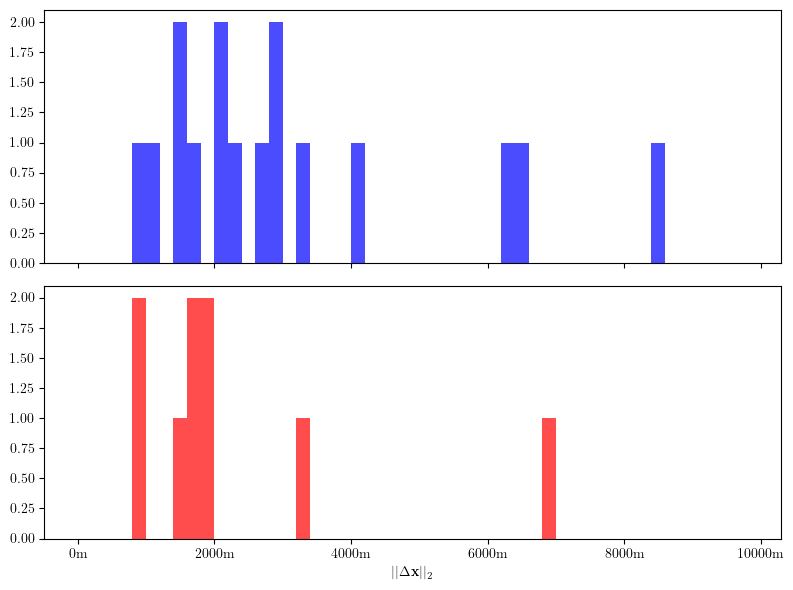

In [41]:
inlier_positions = np.logical_and.reduce(~np.isnan(pred_ransac_test), axis=(1, 2))
err_inliers = (
    LA.norm(
        pred_ransac_test[inlier_positions] - true_position_test[inlier_positions],
        axis=1,
    ).ravel()
    * 1000
)
verified_positions = np.logical_and.reduce(
    ~np.isnan(pred_reprojection_test), axis=(1, 2)
)
err_verified = (
    LA.norm(
        pred_reprojection_test[verified_positions]
        - true_position_test[verified_positions],
        axis=1,
    ).ravel()
    * 1000
)
bins = np.arange(0, 10000, 200)
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex="all", sharey="all")

axes[0].hist(err_inliers, bins=bins, color="blue", alpha=0.7)
axes[0].xaxis.set_major_formatter(ticker.FormatStrFormatter("%.im"))

axes[1].hist(err_verified, bins=bins, color="red", alpha=0.7)
axes[1].set_xlabel("$||\Delta \mathbf{x}||_2$")
axes[1].xaxis.set_major_formatter(ticker.FormatStrFormatter("%.im"))

fig.tight_layout()
fig.savefig("../output/total_error.pdf")
len(err_inliers), len(err_verified)

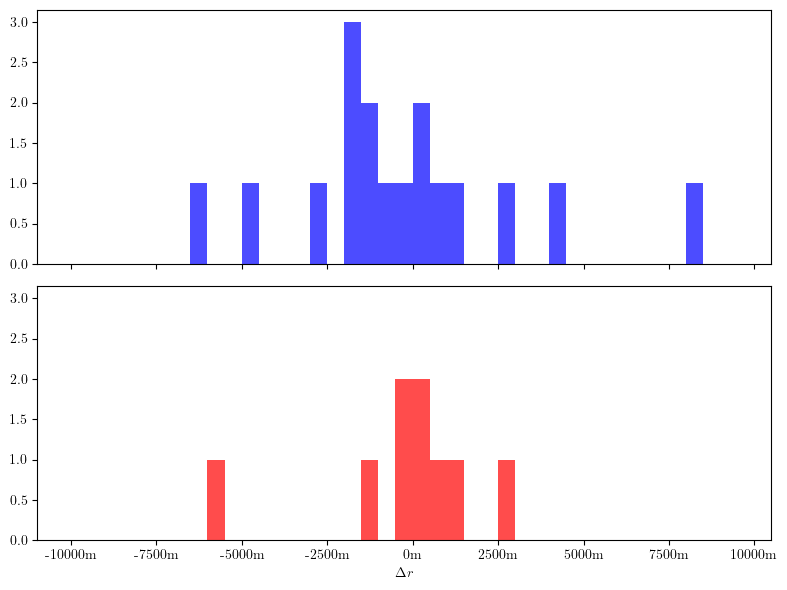

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex="all", sharey="all")


for pred, true, color, ax in zip(
    [pred_ransac_test[inlier_positions], pred_reprojection_test[verified_positions]],
    [true_position_test[inlier_positions], true_position_test[verified_positions]],
    ["blue", "red"],
    axes,
):
    err_r, err_lat_rad, err_lon_rad = np.array(
        cartesian_to_spherical(*pred.squeeze().T)
        - np.array(cartesian_to_spherical(*true.squeeze().T))
    )

    err_lat, err_lon = map(np.degrees, (err_lat_rad, err_lon_rad))

    err_lon[err_lon > 180] -= 360

    ax.hist(err_r * 1000, bins=np.arange(-10000, 10000, 500), color=color, alpha=0.7)
axes[1].set_xlabel(r"$\Delta r$")
axes[1].xaxis.set_major_formatter(ticker.FormatStrFormatter("%.im"))
fig.tight_layout()
fig.savefig("../output/radial_error.pdf")

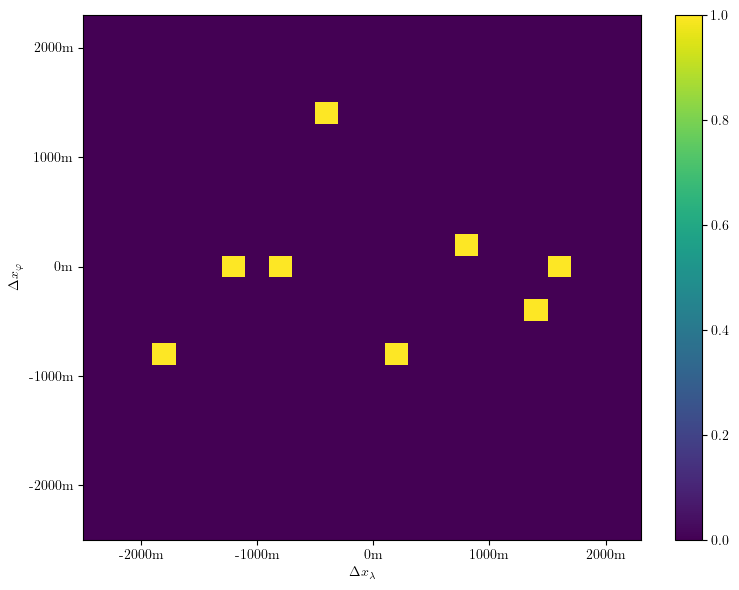

In [43]:
err_r, err_lat_rad, err_lon_rad = np.array(
    cartesian_to_spherical(*(pred).squeeze().T)
    - np.array(cartesian_to_spherical(*(true).squeeze().T))
)

err_lat, err_lon = map(np.degrees, (err_lat_rad, err_lon_rad))
fig, ax = plt.subplots(figsize=(8, 6))
err_range = np.arange(-2500, 2500, 200)
h = ax.hist2d(
    LA.norm(true_position_test[verified_positions], axis=(1, 2)) * err_lon_rad * 1e3,
    LA.norm(true_position_test[verified_positions], axis=(1, 2)) * err_lat_rad * 1e3,
    bins=err_range,
    cmap="viridis",
)
ax.set_xlabel(r"$\Delta x_{\lambda}$")
ax.set_ylabel(r"$\Delta x_{\varphi}$")
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%im"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%im"))
plt.colorbar(h[3], ax=ax)
fig.tight_layout()
fig.savefig("../output/coordinate_error.pdf")

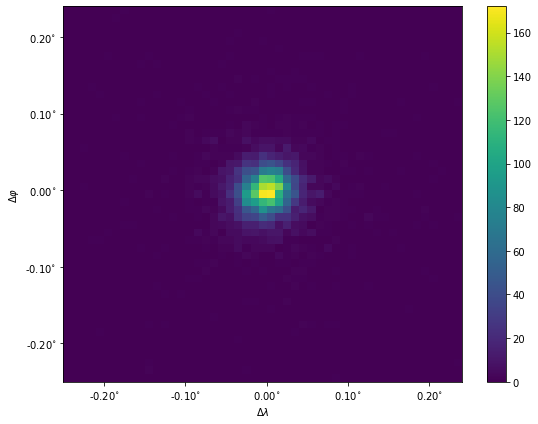

In [165]:
fig, ax = plt.subplots(figsize=(8, 6))
err_range = np.arange(-0.25, 0.25, 0.01)
h = ax.hist2d(err_lon, err_lat, bins=err_range, cmap="viridis")
ax.set_xlabel(r"$\Delta \lambda$")
ax.set_ylabel(r"$\Delta \varphi$")
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f$^{\circ}$"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f$^{\circ}$"))
plt.colorbar(h[3], ax=ax)
fig.tight_layout()
fig.savefig("../output/coordinate_error_degrees.pdf")

19951872.380152795

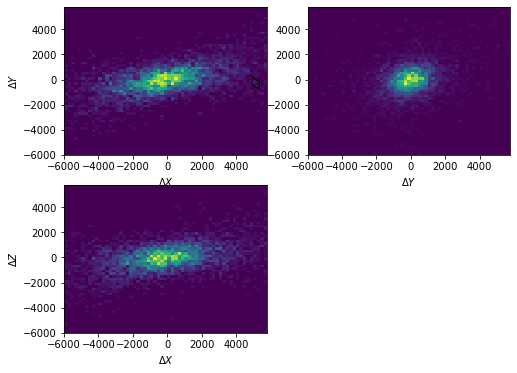

In [166]:
err_x, err_y, err_z = (
    (
        (
            pred_reprojection_test[verified_positions]
            - true_position_test[verified_positions]  
        )
        * 1000
    )
    .squeeze()
    .T
)
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

err_range = np.arange(-6000, 6000, 200)

h = ax[0, 0].hist2d(err_x, err_y, bins=err_range, cmap="viridis")
ax[0, 0].set_xlabel("$\Delta X$")
ax[0, 0].set_ylabel("$\Delta Y$")

ax[1, 0].hist2d(err_x, err_z, bins=err_range, cmap="viridis")
ax[1, 0].set_xlabel("$\Delta X$")
ax[1, 0].set_ylabel("$\Delta Z$")

ax[0, 1].hist2d(err_y, err_z, bins=err_range, cmap="viridis")
ax[0, 1].set_xlabel("$\Delta Y$")
ax[0, 1].set_ylabel("$\Delta Z$")

ax[1, 1].axis("off")
# plt.colorbar(h[3], ax=ax[1, 1])
np.nanmean(err_x)

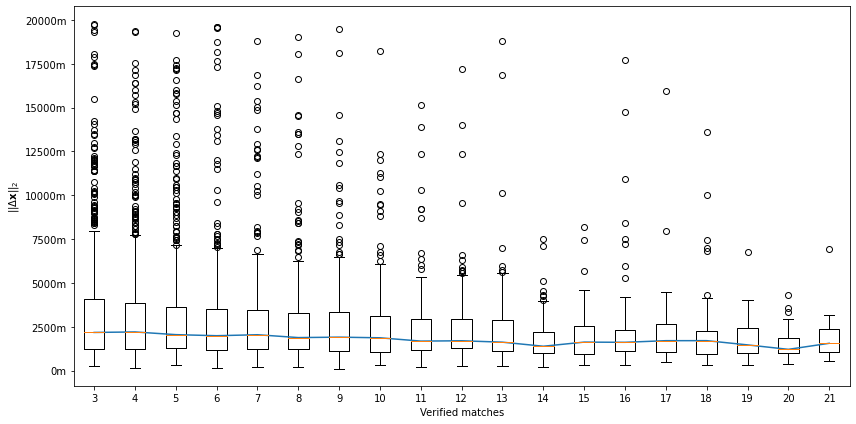

In [167]:
dist_filter = err_verified < 20e3
fig, ax = plt.subplots(figsize=(12, 6))
n = n_verified_test[verified_positions][dist_filter]
e = err_verified[dist_filter]
data = []
ticklabels = []
medians = []
for i, c in zip(*np.unique(n_verified_test, return_counts=True)):
    if c < 30 or i <= 2:
        continue
    data.append(e[n == i])
    ticklabels.append(int(i))
    medians.append(np.median(e[n == i]))

ax.boxplot(data, positions=ticklabels)
ax.plot(ticklabels, medians)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%im"))
ax.set_xlabel("Verified matches")
ax.set_ylabel("$||\Delta \mathbf{x}||_2$")
fig.tight_layout()
fig.savefig("../output/verification_accuracy_boxplot.pdf")

[1001.660067954816, 1110.254363916185, 1399.5121786361804, 1783.2973180140593, 2268.329842108414, 2921.641474608653]


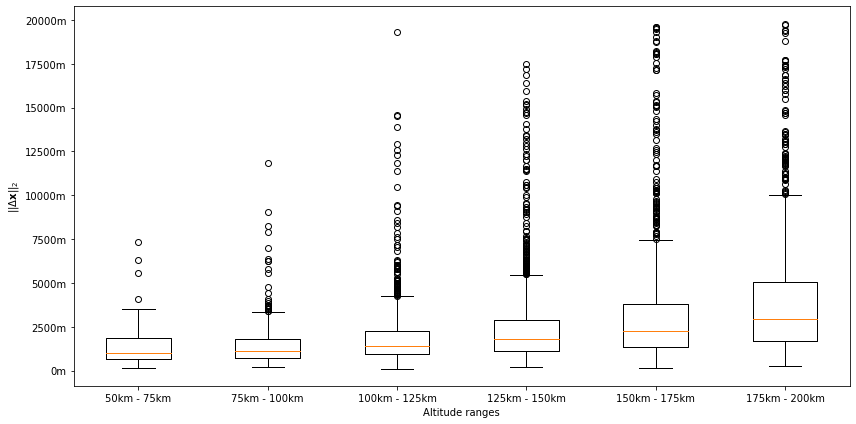

In [173]:
dist_filter = err_verified < 20e3
fig, ax = plt.subplots(figsize=(12, 6))
n = n_verified_test[verified_positions][dist_filter]
data = []
ticklabels = []
medians = []

height_levels = np.arange(50, 201, 25)

for h_min, h_max in zip(height_levels[:-1], height_levels[1:]):

    h = LA.norm(true_position_test[verified_positions][dist_filter], axis=(1, 2))
    f = np.logical_and(h_min < (h - const.RMOON), (h - const.RMOON) < h_max)
    if f.sum() < 20:
        continue
    d = err_verified[dist_filter][f]
    medians.append(np.median(d))

    data.append(d)
    ticklabels.append(f"{h_min}km - {h_max}km")

ax.boxplot(data)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%im"))
ax.set_xticklabels(ticklabels)
ax.set_xlabel("Altitude ranges")
ax.set_ylabel("$||\Delta \mathbf{x}||_2$")
fig.tight_layout()
fig.savefig("../output/altitude_accuracy_boxplot.pdf")
print(medians)

In [ ]:
np.arange(80, 301, 20)